In [1]:
import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from keras import layers
import openpyxl as xl
from openpyxl.styles import Font
from scipy import optimize 
from scipy import integrate
import copy
import os

In [2]:
#Coletando dados 

df = pd.read_excel(r'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Sergipe\1-Crustaceos\R.xlsx')


df_especies = pd.DataFrame(df[['Ano',"Camarao_sete_barbas_art",   "Camarao_rosa_art",   "Camarao_branco_art",   "Caranguejo_uca_art",   "Aratu_art",   "Guaiamum_art",   "Siri_art",   "Lagosta_art"]])
inicio_pesca = pd.read_excel(r'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Sergipe\1-Crustaceos\I.xlsx')



lista_de_pesca = [] #lista onde ficam os arrays com as pescas de cada especias
lista_de_anos_Sergipe_prever = []
lista_anos_com_dados = []

especies = df_especies.drop('Ano',axis=1).columns.to_numpy()

for k in range(len(especies)):
    dados = df_especies[['Ano',especies[k]]].dropna()

    #achando os anos Sergipe\ prever da especie
    anos_Sergipe_prever = []
    for i in range(len(inicio_pesca.iloc[:,0])):
        if inicio_pesca.loc[i,'Variavel'] == especies[k]:
            inicio = inicio_pesca.loc[i,'Ano_inicio']
            fim = inicio_pesca.loc[i,'Ano_final']
    anos = np.arange(inicio,fim+1)
    for i in anos:
        if pd.isnull(df_especies.loc[i-1950,especies[k]])==True:
            anos_Sergipe_prever.append(i)

    anos_Sergipe_prever = np.array(anos_Sergipe_prever)   
    print(anos_Sergipe_prever)
    lista_de_anos_Sergipe_prever.append(anos_Sergipe_prever)

    anos_com_dados = dados["Ano"].values
    lista_anos_com_dados.append(anos_com_dados)

    todos_anos = np.concatenate((anos_Sergipe_prever, anos_com_dados))
    todos_anos.sort()
    
    pesca = dados[especies[k]].values
    lista_de_pesca.append(pesca)
    print(dados.head())

[2008 2009 2017]
    Ano  Camarao_sete_barbas_art
0  1950                 8.326061
1  1951                13.996434
2  1952                17.984930
3  1953                22.097713
4  1954                14.427757
[2008 2009 2017]
    Ano  Camarao_rosa_art
0  1950          1.704766
1  1951          2.877202
2  1952          3.711892
3  1953          4.579010
4  1954          3.001697
[2008 2009 2017]
    Ano  Camarao_branco_art
0  1950            0.196803
1  1951            0.331410
2  1952            0.426598
3  1953            0.525073
4  1954            0.343428
[1990 1991 1992 1993 1994 2008 2009 2017]
    Ano  Caranguejo_uca_art
0  1950           49.065753
1  1951           85.703029
2  1952          114.683681
3  1953          146.820885
4  1954           99.720421
[1990 1991 1992 1993 1994 2008 2009 2017]
     Ano   Aratu_art
28  1978   17.502176
29  1979   14.001741
30  1980  151.393820
31  1981   11.376414
32  1982   17.502176
[1990 1991 1992 1993 1994 2008 2009 2017]
     An

In [3]:
#Normalização dos dados
lista_pesca_norm=[]  #lista com as pescas normalizads Sergipe\ cada especie
lista_pesca_mean=[]  #listas Sergipe\ aplicar a inversa da normalização
lista_pesca_std=[]

lista_ano_mean=[]
lista_ano_std=[]
lista_anos_com_dados_norm=[]
lista_de_anos_Sergipe_prever_norm=[]

for k in range(len(especies)):
    ano_mean = np.mean(lista_anos_com_dados[k])
    ano_std = np.std(lista_anos_com_dados[k])
    anos_Sergipe_prever_norm = (lista_de_anos_Sergipe_prever[k] - ano_mean)/ano_std
    anos_com_dados_norm = (lista_anos_com_dados[k] - ano_mean)/ano_std
    
    lista_anos_com_dados_norm.append(anos_com_dados_norm)
    lista_ano_mean.append(ano_mean)
    lista_ano_std.append(ano_std)
    lista_de_anos_Sergipe_prever_norm.append(anos_Sergipe_prever_norm)

    pesca_mean = np.mean(lista_de_pesca[k])
    pesca_std = np.std(lista_de_pesca[k])
    pesca_norm = (lista_de_pesca[k] - pesca_mean)/pesca_std

    lista_pesca_norm.append(pesca_norm)  
    lista_pesca_mean.append(pesca_mean)  
    lista_pesca_std.append(pesca_std)

In [4]:
#Criação das pastas onde serão armazenados os pesos
for esp in especies:
    folder_path = rf'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Sergipe\1-Crustaceos\/Peso_{esp}'
    if not os.path.exists(folder_path):
        os.mkdir(folder_path) 


#Função Sergipe\ fazer o Fit do modelo e salvar seus pesos Sergipe\ cada especie
def Interpolações(lista_anos_com_dados_norm,
                       lista_pesca_norm,
                       lista_de_epocas,
                       lista_de_otimizadores,
                       lista_de_overwrite,
                       especies):
    
    model = keras.Sequential([layers.Dense(96,activation='leaky_relu',input_shape=(1,)),
                                 layers.Dense(32,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(96,activation='leaky_relu'),
                                 layers.Dense(112,activation='leaky_relu'),
                                 layers.Dense(1,activation='linear')])
    
    lista_de_loss=[]
    for k in range(len(especies)):
        opt =  lista_de_otimizadores[k]            #keras.optimizers.Nadam(learning_rate=0.001)
        model.compile(optimizer=opt, loss='mse')
        
        
        history = model.fit(lista_anos_com_dados_norm[k],lista_pesca_norm[k], epochs=lista_de_epocas[k], verbose=0)
        lista_de_loss.append(history.history['loss'])

        
        model.save_weights(rf'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Sergipe\1-Crustaceos/Peso_{especies[k]}/.weights.h5', overwrite=lista_de_overwrite[k])
    return model,lista_de_loss


In [5]:
#Fit do modelo
Nadam= keras.optimizers.Nadam(learning_rate=0.001)
Adam= keras.optimizers.Adam(learning_rate=0.001)

lista_de_epocas=[500,500,500,500,500,500,500,500,500,500]
lista_de_otimizadores=[Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam]
lista_de_overwrite = [True,True,True,True,True,True,True,True,True,True]
model,lista_de_loss = Interpolações(lista_anos_com_dados_norm,
                                         lista_pesca_norm,
                                         lista_de_epocas,
                                         lista_de_otimizadores,
                                         lista_de_overwrite,
                                         especies)

c:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
#Previsões Sergipe\ cada especie
lista_de_previsoes=[]
lista_fits=[]

p = np.linspace(-2,2,50)
for k in range(len(especies)):
    
    model.load_weights(rf'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Sergipe\1-Crustaceos/Peso_{especies[k]}/.weights.h5')

    prev_ausentes = model.predict(lista_de_anos_Sergipe_prever_norm[k])*lista_pesca_std[k] + lista_pesca_mean[k]
    fit = model.predict(p)*lista_pesca_std[k] + lista_pesca_mean[k]
    #Colocando valores negativos Sergipe\ 0 e proporções no maximo 1
    for i in range(len(prev_ausentes)):
        if prev_ausentes[i]<0:
            prev_ausentes[i]=0


    lista_de_previsoes.append(prev_ausentes)
    lista_fits.append(fit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


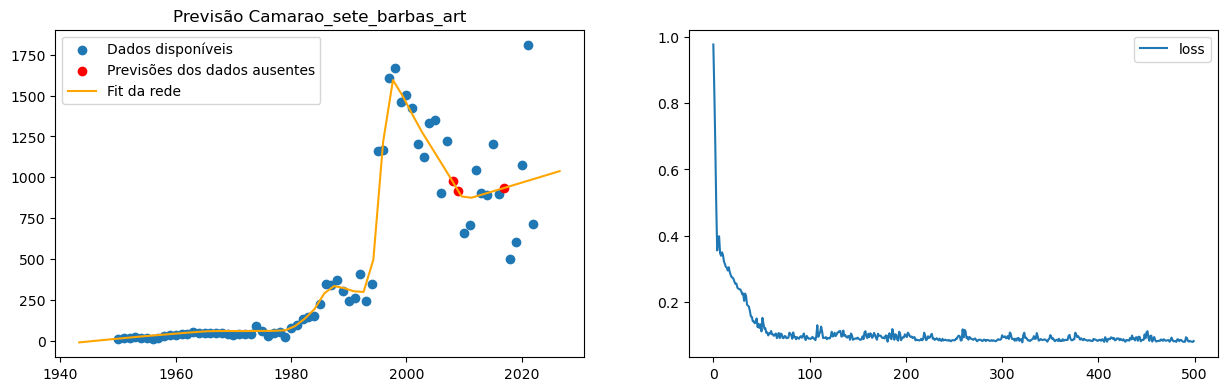

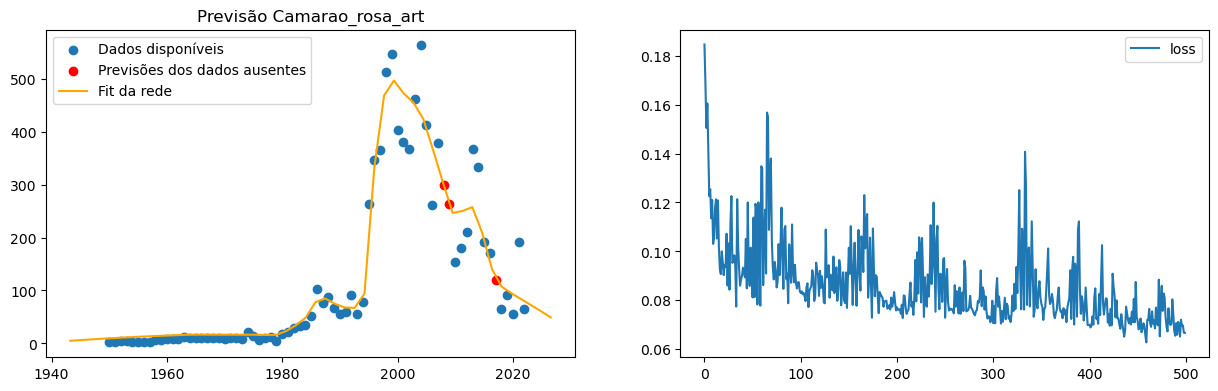

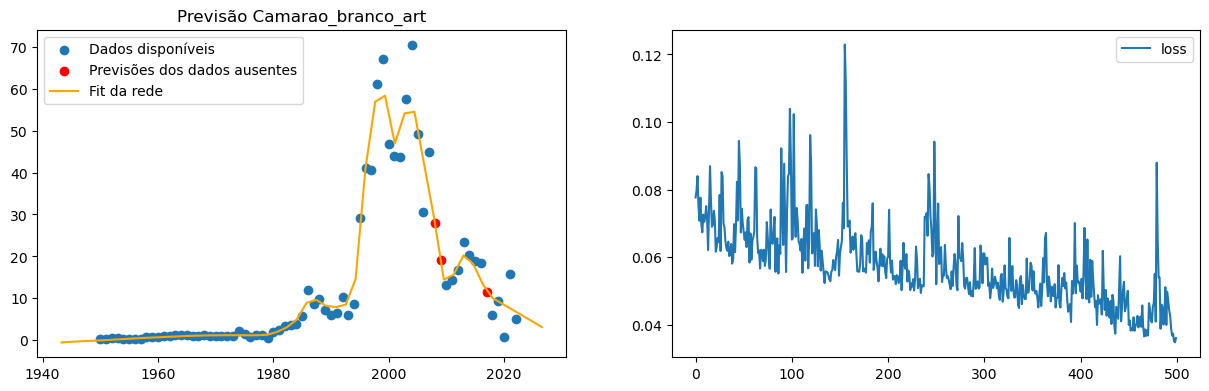

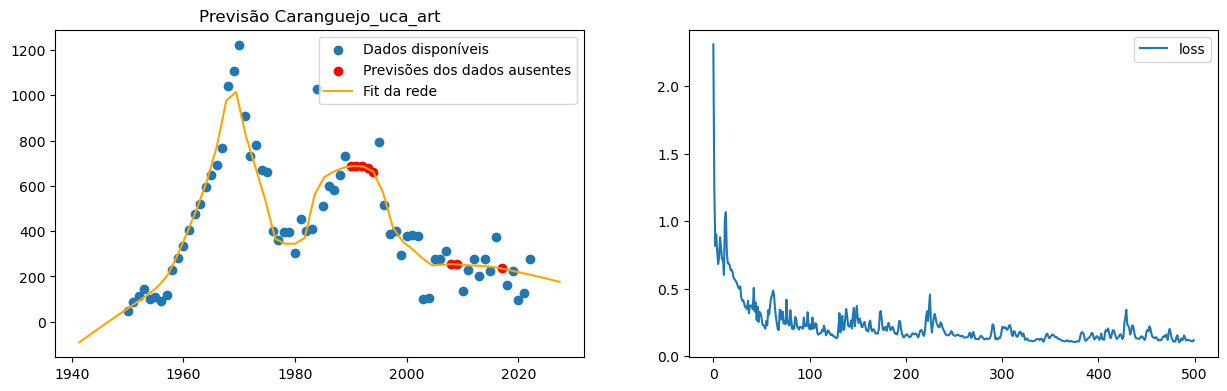

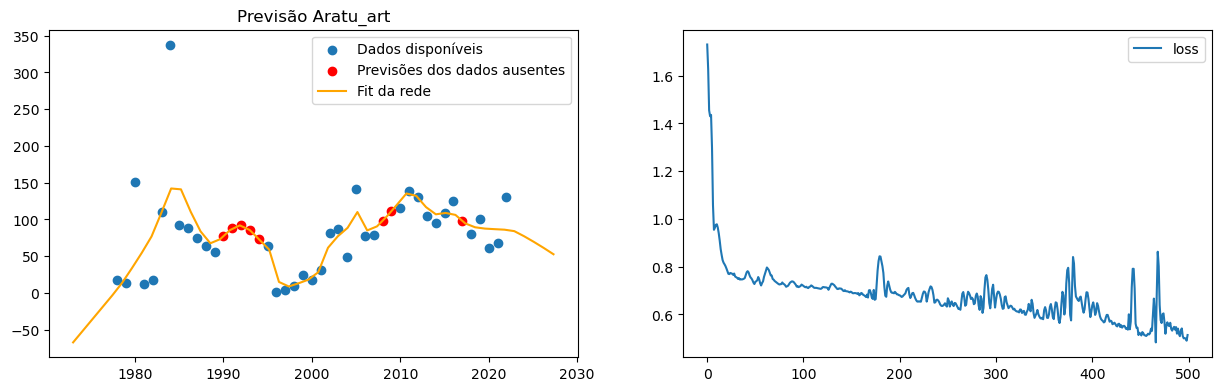

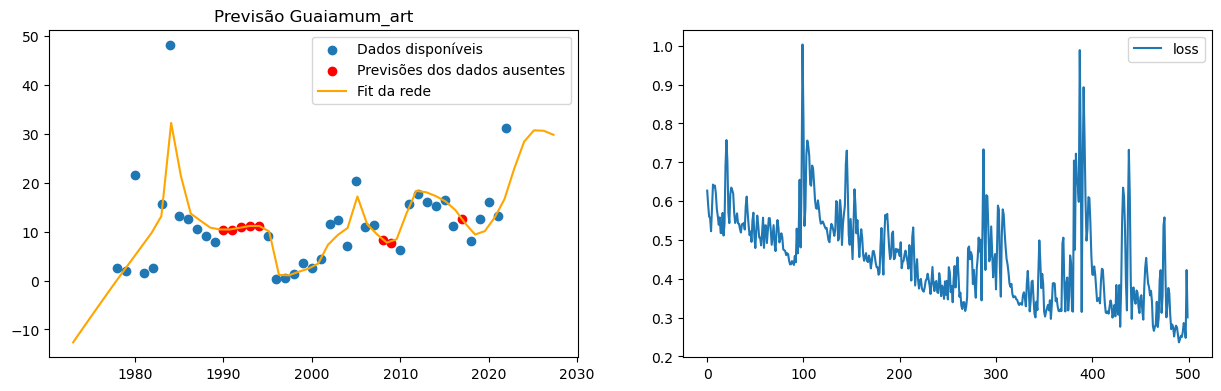

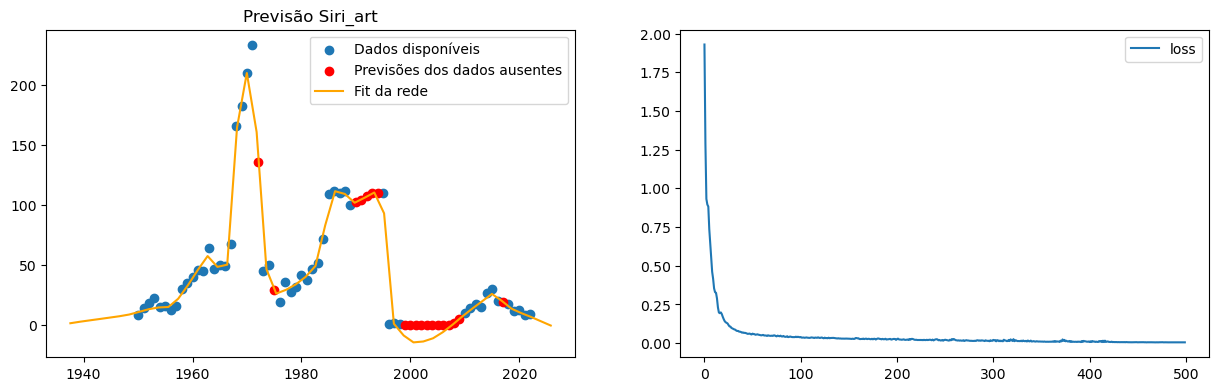

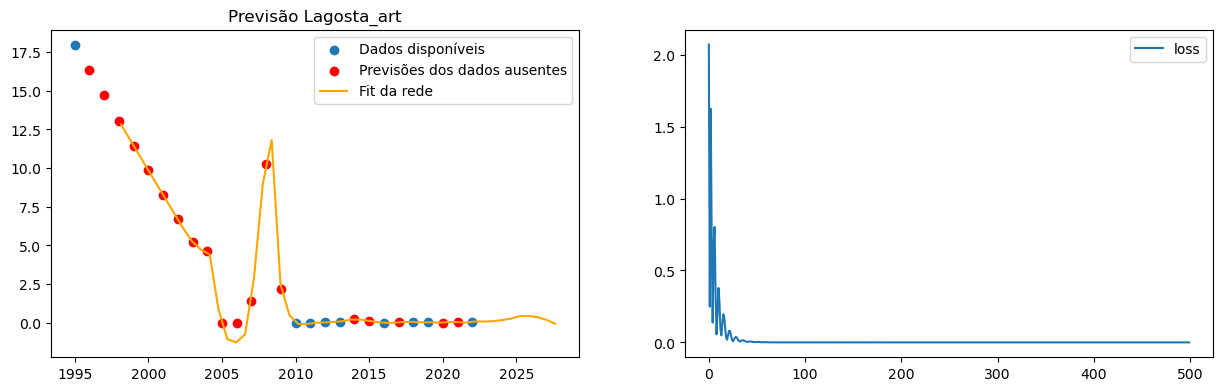

In [7]:
#Plot das previsoes e loss Sergipe\ cada especie
for k in range(len(especies)):
    plt.figure(figsize=(15,5*len(especies)))
    plt.subplot(len(especies),2,2*k+1 ).scatter(lista_anos_com_dados[k],lista_de_pesca[k],label='Dados disponíveis')
    plt.subplot(len(especies),2,2*k+1 ).scatter(lista_de_anos_Sergipe_prever[k],lista_de_previsoes[k], color='red', label='Previsões dos dados ausentes')
    plt.subplot(len(especies),2,2*k+1 ).plot(p*lista_ano_std[k] + lista_ano_mean[k],lista_fits[k],color='orange',label='Fit da rede')
    plt.title(f'Previsão {especies[k]}')
    plt.legend()

    plt.subplot(len(especies),2,2*k+2).plot(lista_de_loss[k],label='loss')
    plt.legend()

plt.show()

In [8]:
#Adicionando aleatoriedade
lista_de_previsoes_rd = copy.deepcopy(lista_de_previsoes)

#Distribuição normal
def normal(x,med,std):
    return (1/(std*np.sqrt(2*np.pi)))*np.exp(-0.5*(((x-med)/std)**2))

#Função Sergipe\ calcular o intervalo de confiança de 90%
def g(k,med,std):
    dx = ((med+k*std)-(med-k*std))/10
    x=[]
    y=[]
    for i in range(11):
        x.append((med-k*std)+i*dx)
        y.append(normal((med-k*std)+i*dx,med,std))
    return integrate.simpson(y,x=x) - 0.90


#Dataframe com os dados reconstruídos
df_prev = df[['Ano',"Camarao_sete_barbas_art",   "Camarao_rosa_art",   "Camarao_branco_art",   "Caranguejo_uca_art",   "Aratu_art",   "Guaiamum_art",   "Siri_art",   "Lagosta_art"]]
for k in range(len(especies)):
    for i in range(len(lista_de_anos_Sergipe_prever[k])):
        df_prev.loc[lista_de_anos_Sergipe_prever[k][i]-1950,especies[k]] = lista_de_previsoes[k][i,0]

for k in range(len(especies)):
    for i in range(len(lista_de_anos_Sergipe_prever[k])):

        #Desvios padrao(5 anos)
        
        #anos_considerados=[]
        valores_considerados=[]
        t=-2
        
        if lista_de_anos_Sergipe_prever[k][i]-1950 -2 <0  or pd.isnull(df_prev.loc[lista_de_anos_Sergipe_prever[k][i]-1950-2,especies[k]])==True:
            t=-1
        if lista_de_anos_Sergipe_prever[k][i]-1950 -1 <0  or pd.isnull(df_prev.loc[lista_de_anos_Sergipe_prever[k][i]-1950-1,especies[k]])==True:
            t=0            
        if lista_de_anos_Sergipe_prever[k][i]-1950 -2+4 > 72  or pd.isnull(df_prev.loc[lista_de_anos_Sergipe_prever[k][i]-1950-2+4,especies[k]])==True:
            t=-3
        if lista_de_anos_Sergipe_prever[k][i]-1950 -3+4 > 72  or pd.isnull(df_prev.loc[lista_de_anos_Sergipe_prever[k][i]-1950-3+4,especies[k]])==True:
            t=-4    

        while len(valores_considerados)<5:   
                #anos_considerados.append(lista_de_anos_Sergipe\_prever[k][i]+t)
                valores_considerados.append(df_prev.loc[lista_de_anos_Sergipe_prever[k][i]-1950+t,especies[k]])
                t+=1
        
        #print(lista_de_anos_Sergipe\_prever[k][i],valores_considerados)
        std = np.std(np.array(valores_considerados))
        med = lista_de_previsoes[k][i,0]
        if std!=0:
          #Raiz da função g(k) pelo método da secante
          raiz = optimize.newton(g,1,args=(med,std))
          
          #Gerando valor aleatorio Sergipe\ a previsão(se houver valores positivos no intervalo)
          prev_min = med - std*raiz
          prev_max = med + std*raiz
          if prev_max>0:
              rd=-1
              #A aleatorização é refeita se o resultado for negativo ou zero
              while rd<=0:
                  rd = np.random.choice(np.linspace(prev_min,prev_max,50))
          else:
              print('A espécie',especies[k],'tem valor(es) negativo(s)')
          lista_de_previsoes_rd[k][i,0]=rd

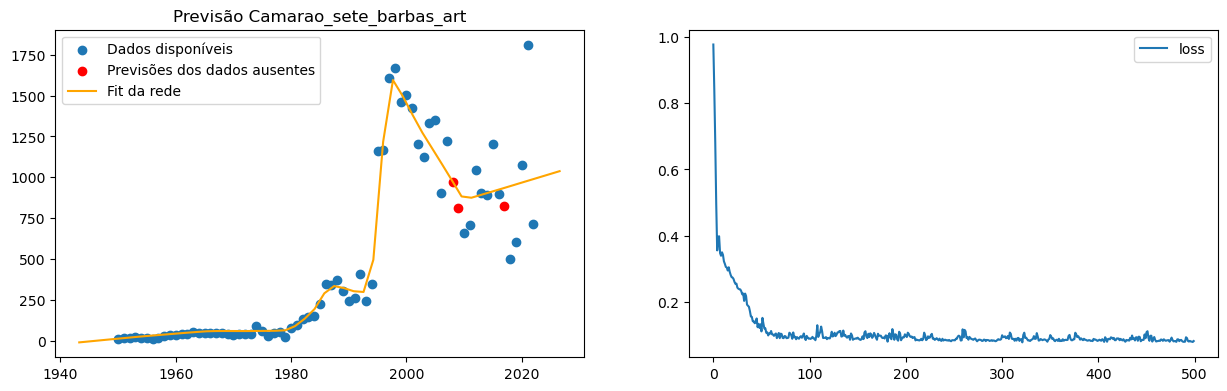

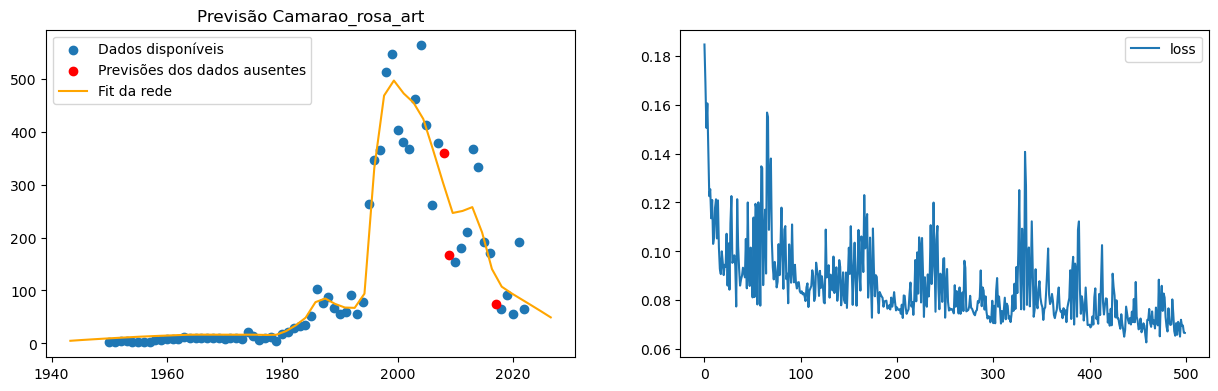

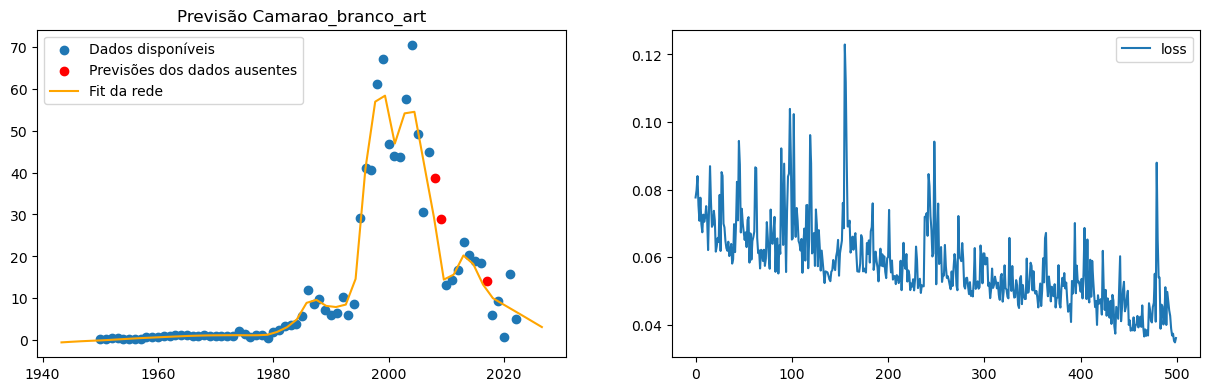

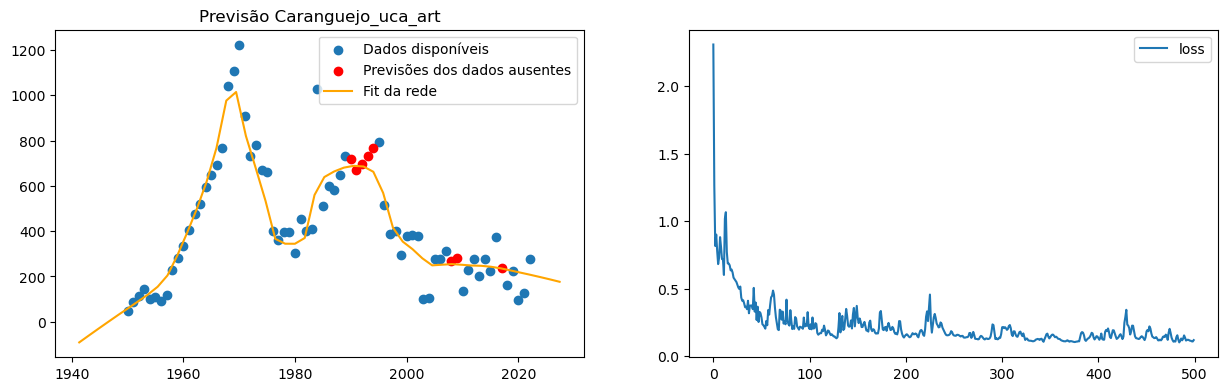

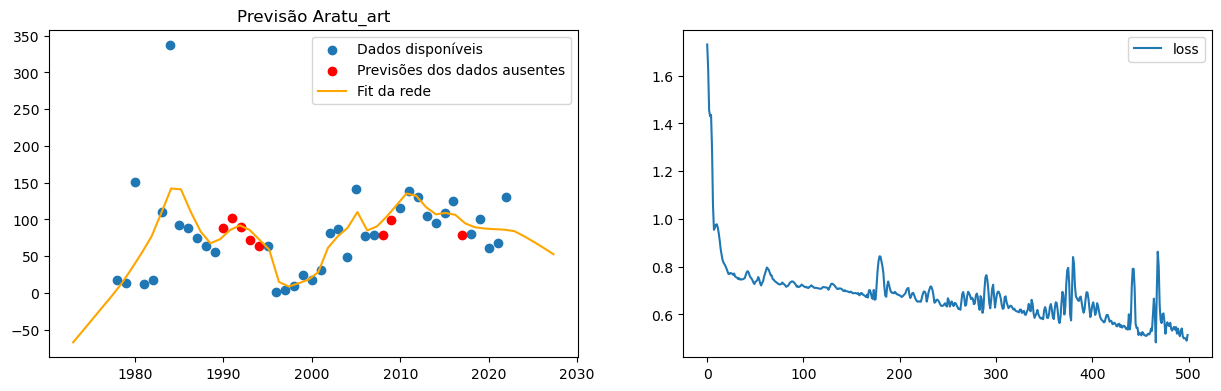

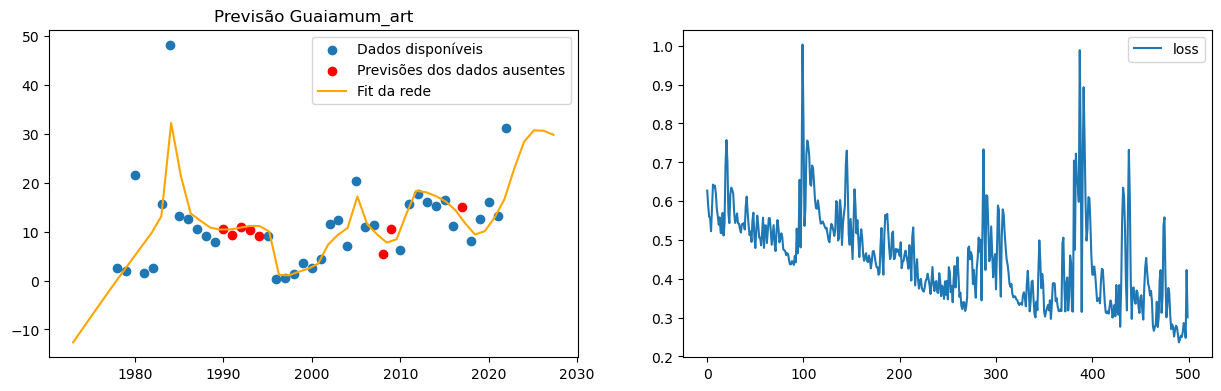

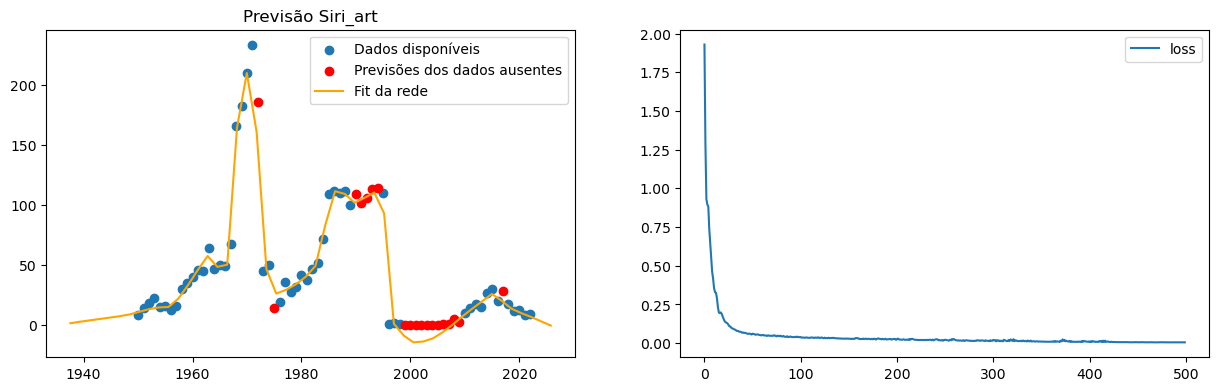

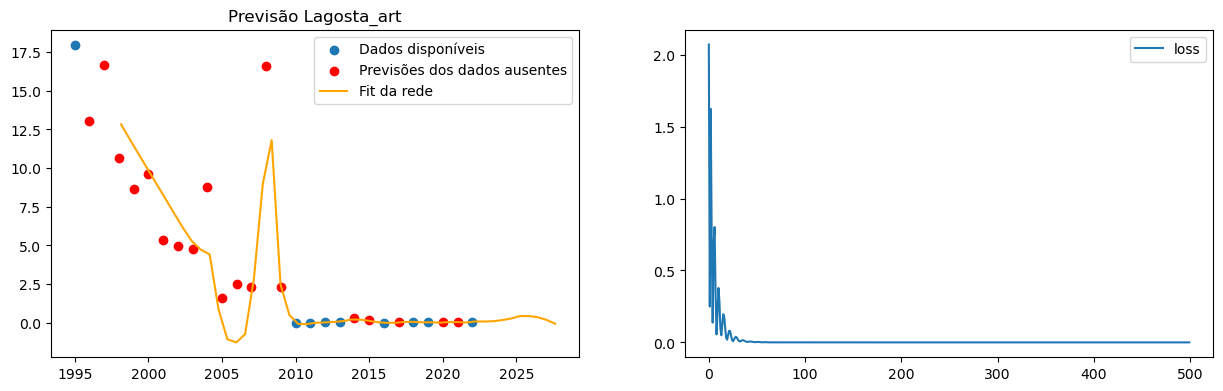

In [9]:
#Plot das previsoes e loss Sergipe\ cada especie
for k in range(len(especies)):
    plt.figure(figsize=(15,5*len(especies)))
    plt.subplot(len(especies),2,2*k+1 ).scatter(lista_anos_com_dados[k],lista_de_pesca[k],label='Dados disponíveis')
    plt.subplot(len(especies),2,2*k+1 ).scatter(lista_de_anos_Sergipe_prever[k],lista_de_previsoes_rd[k], color='red', label='Previsões dos dados ausentes')
    plt.subplot(len(especies),2,2*k+1 ).plot(p*lista_ano_std[k] + lista_ano_mean[k],lista_fits[k],color='orange',label='Fit da rede')
    plt.title(f'Previsão {especies[k]}')
    plt.legend()

    plt.subplot(len(especies),2,2*k+2).plot(lista_de_loss[k],label='loss')
    plt.legend()

plt.show()

In [10]:
#Dicionario dos indices das espécie Sergipe\ prever  (Sergipe\ usar o nome da coluna no openpyxl) 
todas_colunas=df.columns.to_numpy()
dic_especies={}
for k in range(len(especies)):
    for i in range(len(todas_colunas)):
        if especies[k]==todas_colunas[i]:
            dic_especies[especies[k]]=i+1 #Índices do openpyxl
            break

In [11]:
#ws com os dados preenchidos e coloridos(todos vermelhos)
wb = xl.load_workbook(r'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Sergipe\1-Crustaceos\R.xlsx')
ws = wb.active

for k in range(len(especies)):
    for i in range(len(lista_de_anos_Sergipe_prever[k])):
        celula=ws.cell(lista_de_anos_Sergipe_prever[k][i]-1950+2 , dic_especies[especies[k]])
        celula.value = lista_de_previsoes_rd[k][i,0]
        celula.font = Font(color='FFFF0000',name='Calibri')


wb.save('Interpolações.xlsx')


In [12]:
   ###Caso o openpyxl não coloque todos os valores###



df_prev = df[['Ano',"Camarao_sete_barbas_art",   "Camarao_rosa_art",   "Camarao_branco_art",   "Caranguejo_uca_art",   "Aratu_art",   "Guaiamum_art",   "Siri_art",   "Lagosta_art"]]
for k in range(len(especies)):
    for i in range(len(lista_de_anos_Sergipe_prever[k])):
        df_prev.loc[lista_de_anos_Sergipe_prever[k][i]-1950,especies[k]] = lista_de_previsoes_rd[k][i,0]
df_prev.to_excel('Interpol pandas.xlsx')